# Machine Learning Engineer Nanodegree
## Unsupervised Learning
## Project: Creating Customer Segments

Welcome to the third project of the Machine Learning Engineer Nanodegree! In this notebook, some template code has already been provided for you, and it will be your job to implement the additional functionality necessary to successfully complete this project. Sections that begin with **'Implementation'** in the header indicate that the following block of code will require additional functionality which you must provide. Instructions will be provided for each section and the specifics of the implementation are marked in the code block with a `'TODO'` statement. Please be sure to read the instructions carefully!

In addition to implementing code, there will be questions that you must answer which relate to the project and your implementation. Each section where you will answer a question is preceded by a **'Question X'** header. Carefully read each question and provide thorough answers in the following text boxes that begin with **'Answer:'**. Your project submission will be evaluated based on your answers to each of the questions and the implementation you provide.  

>**Note:** Code and Markdown cells can be executed using the **Shift + Enter** keyboard shortcut. In addition, Markdown cells can be edited by typically double-clicking the cell to enter edit mode.

## Getting Started

In this project, you will analyze a dataset containing data on various customers' annual spending amounts (reported in *monetary units*) of diverse product categories for internal structure. One goal of this project is to best describe the variation in the different types of customers that a wholesale distributor interacts with. Doing so would equip the distributor with insight into how to best structure their delivery service to meet the needs of each customer.

The dataset for this project can be found on the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/Wholesale+customers). For the purposes of this project, the features `'Channel'` and `'Region'` will be excluded in the analysis — with focus instead on the six product categories recorded for customers.

Run the code block below to load the wholesale customers dataset, along with a few of the necessary Python libraries required for this project. You will know the dataset loaded successfully if the size of the dataset is reported.

In [1]:
# Import libraries necessary for this project
import numpy as np
import pandas as pd
from IPython.display import display # Allows the use of display() for DataFrames
import matplotlib.pyplot as plt
# Import supplementary visualizations code visuals.py
import visuals as vs

# Pretty display for notebooks
%matplotlib inline

# Load the wholesale customers dataset
try:
    data = pd.read_csv("customers.csv")
    data.drop(['Region', 'Channel'], axis = 1, inplace = True)
    print("Wholesale customers dataset has {} samples with {} features each.".format(*data.shape))
except:
    print("Dataset could not be loaded. Is the dataset missing?")

Wholesale customers dataset has 440 samples with 6 features each.


In [2]:
data.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


## Data Exploration
In this section, you will begin exploring the data through visualizations and code to understand how each feature is related to the others. You will observe a statistical description of the dataset, consider the relevance of each feature, and select a few sample data points from the dataset which you will track through the course of this project.

Run the code block below to observe a statistical description of the dataset. Note that the dataset is composed of six important product categories: **'Fresh'**, **'Milk'**, **'Grocery'**, **'Frozen'**, **'Detergents_Paper'**, and **'Delicatessen'**. Consider what each category represents in terms of products you could purchase.

In [3]:
# Display a description of the dataset
display(data.describe())

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


### Implementation: Selecting Samples
To get a better understanding of the customers and how their data will transform through the analysis, it would be best to select a few sample data points and explore them in more detail. In the code block below, add **three** indices of your choice to the `indices` list which will represent the customers to track. It is suggested to try different sets of samples until you obtain customers that vary significantly from one another.

In [4]:
# TODO: Select three indices of your choice you wish to sample from the dataset
indices = [0 , 6 , 2]

# Create a DataFrame of the chosen samples
samples = pd.DataFrame(data.loc[indices], columns = data.keys()).reset_index(drop = True)
print("Chosen samples of wholesale customers dataset:")
display(samples)

Chosen samples of wholesale customers dataset:


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,12126,3199,6975,480,3140,545
2,6353,8808,7684,2405,3516,7844


### Question 1
Consider the total purchase cost of each product category and the statistical description of the dataset above for your sample customers.  

* What kind of establishment (customer) could each of the three samples you've chosen represent?

**Hint:** Examples of establishments include places like markets, cafes, delis, wholesale retailers, among many others. Avoid using names for establishments, such as saying *"McDonalds"* when describing a sample customer as a restaurant. You can use the mean values for reference to compare your samples with. The mean values are as follows:

* Fresh: 12000.2977
* Milk: 5796.2
* Grocery: 7951.3
* Frozen: 3071.9
* Detergents_paper: 2881.4
* Delicatessen: 1524.8

Knowing this, how do your samples compare? Does that help in driving your insight into what kind of establishments they might be? 


**Answer:**

### Customer 0 
| Feature          | Value   |
| ---------------- | ------- |
| Fresh            | 12669 ↑ |
| Milk             | 9656 ↑  |
| Grocery          | 7561 ≈  |
| Frozen           | 214 ↓↓↓ |
| Detergents_Paper | 2674 ≈  |
| Delicatessen     | 1338 ≈  |

* Buys a lot of fresh products and milk.
* Almost no frozen products.
* Average grocery and cleaning products.

Possible establishment: Restaurant, café, or hotel kitchen that relies on fresh ingredients rather than frozen food.

### Customer 1
| Feature          | Value   |
| ---------------- | ------- |
| Fresh            | 12126 ≈ |
| Milk             | 3199 ↓  |
| Grocery          | 6975 ↓  |
| Frozen           | 480 ↓↓↓ |
| Detergents_Paper | 3140 ↑  |
| Delicatessen     | 545 ↓   |

* Spending is relatively low across most food categories.
* Slightly above-average spending on detergents/paper.

Possible establishment: Small retail store, convenience shop, or wholesaler that stocks packaged goods and cleaning supplies more than fresh food.

### Customer 2
| Feature          | Value    |
| ---------------- | -------- |
| Fresh            | 6353 ↓   |
| Milk             | 8808 ↑   |
| Grocery          | 7684 ≈   |
| Frozen           | 2405 ≈   |
| Detergents_Paper | 3516 ↑   |
| Delicatessen     | 7844 ↑↑↑ |

* Very high delicatessen purchases.
* High milk and detergents.
* Lower fresh products.

Possible establishment: Deli, specialty food shop, gourmet market, or supermarket with a large prepared-food section.

* **Customer 0 appears to represent a restaurant or café because spending on Fresh and Milk products is above average while Frozen purchases are extremely low, suggesting a preference for fresh ingredients.**

* **Customer 1 appears to be a small retailer or convenience store. Spending on most food categories is below average, while Detergents_Paper purchases are slightly above average, indicating a focus on packaged and household products.**

* **Customer 2 appears to be a delicatessen or specialty food market. The customer spends significantly more than average on Delicatessen products and above average on Milk and Detergents_Paper, suggesting a business that sells prepared or specialty foods.**

### Implementation: Feature Relevance
One interesting thought to consider is if one (or more) of the six product categories is actually relevant for understanding customer purchasing. That is to say, is it possible to determine whether customers purchasing some amount of one category of products will necessarily purchase some proportional amount of another category of products? We can make this determination quite easily by training a supervised regression learner on a subset of the data with one feature removed, and then score how well that model can predict the removed feature.

In the code block below, you will need to implement the following:
 - Assign `new_data` a copy of the data by removing a feature of your choice using the `DataFrame.drop` function.
 - Use `sklearn.model_selection.train_test_split` to split the dataset into training and testing sets.
   - Use the removed feature as your target label. Set a `test_size` of `0.25` and set a `random_state`.
 - Import a decision tree regressor, set a `random_state`, and fit the learner to the training data.
 - Report the prediction score of the testing set using the regressor's `score` function.

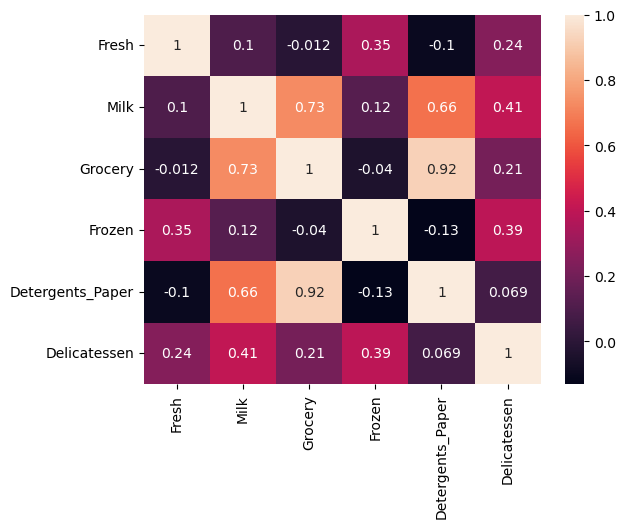

In [5]:
import seaborn as sns

sns.heatmap(data.corr(), annot=True)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

In [7]:
# TODO: Make a copy of the DataFrame, using the 'drop' function to drop the given feature
new_data = data.drop('Grocery', axis=1)

y = data['Grocery']

In [8]:
# TODO: Split the data into training and testing sets(0.25) using the given feature as the target
# Set a random state.
X_train, X_test, y_train, y_test = train_test_split(new_data, y, test_size=0.25, random_state=42)

# TODO: Create a decision tree regressor and fit it to the training set
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

# TODO: Report the score of the prediction using the testing set
score = regressor.score(X_test, y_test)

print(score)

0.6818840085440834


### Question 2

* Which feature did you attempt to predict? 
* What was the reported prediction score? 
* Is this feature necessary for identifying customers' spending habits?

**Hint:** The coefficient of determination, `R^2`, is scored between 0 and 1, with 1 being a perfect fit. A negative `R^2` implies the model fails to fit the data. If you get a low score for a particular feature, that lends us to beleive that that feature point is hard to predict using the other features, thereby making it an important feature to consider when considering relevance.

**Answer:**

* Feature predicted: Grocery
* Prediction score (R²): 0.6819

**I attempted to predict the Grocery feature using the remaining five features. The Decision Tree Regressor achieved an R² score of 0.6819, meaning that about 68% of the variance in Grocery spending can be explained by the other features. Since the score is relatively high, Grocery appears to be strongly related to the other product categories and may contain some redundant information. Therefore, it is likely not one of the most essential features for identifying unique customer spending habits compared to features that are harder to predict from the remaining data.**

### Visualize Feature Distributions
To get a better understanding of the dataset, we can construct a scatter matrix of each of the six product features present in the data. If you found that the feature you attempted to predict above is relevant for identifying a specific customer, then the scatter matrix below may not show any correlation between that feature and the others. Conversely, if you believe that feature is not relevant for identifying a specific customer, the scatter matrix might show a correlation between that feature and another feature in the data. Run the code block below to produce a scatter matrix.

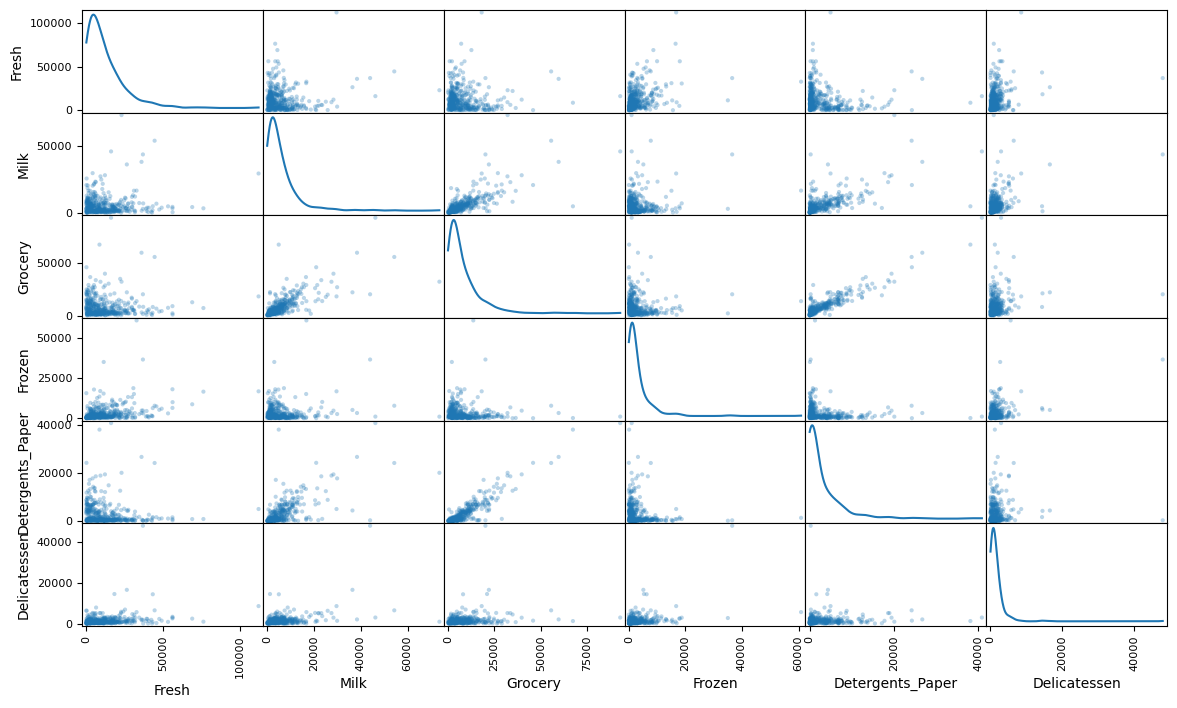

In [9]:
# Produce a scatter matrix for each pair of features in the data
pd.plotting.scatter_matrix(data, alpha = 0.3, figsize = (14,8), diagonal = 'kde');

### Question 3
* Using the scatter matrix as a reference, discuss the distribution of the dataset, specifically talk about the normality, outliers, large number of data points near 0 among others. If you need to sepearate out some of the plots individually to further accentuate your point, you may do so as well.
* Are there any pairs of features which exhibit some degree of correlation? 
* Does this confirm or deny your suspicions about the relevance of the feature you attempted to predict? 
* How is the data for those features distributed?

**Hint:** Is the data normally distributed? Where do most of the data points lie? You can use [corr()](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.corr.html) to get the feature correlations and then visualize them using a [heatmap](http://seaborn.pydata.org/generated/seaborn.heatmap.html)(the data that would be fed into the heatmap would be the correlation values, for eg: `data.corr()`) to gain further insight.

**Answer:**
*  **The scatter matrix shows that the data is not normally distributed. Most features are heavily right-skewed, with a large concentration of observations near zero and a small number of customers exhibiting very high spending values. These extreme values appear as outliers in several features, particularly Fresh, Milk, Grocery, and Detergents_Paper.**

*  **Several feature pairs exhibit strong positive correlations. The strongest relationship is between Grocery and Detergents_Paper, with a correlation coefficient of approximately 0.92. Milk also shows strong positive correlations with both Grocery and Detergents_Paper. In contrast, Fresh and Frozen appear to have relatively weak correlations with most other features.**

*  **These observations support the results from the feature relevance analysis. Since Grocery can be predicted reasonably well from the remaining features (R² ≈ 0.68), it appears to share substantial information with other variables, particularly Detergents_Paper and Milk. This suggests that Grocery is somewhat redundant compared to features that are less predictable from the rest of the dataset.**

*  **Overall, the data contains significant skewness, numerous outliers, and several strongly correlated feature pairs. Therefore, applying a logarithmic transformation is appropriate before performing dimensionality reduction and clustering.**

## Data Preprocessing
In this section, you will preprocess the data to create a better representation of customers by performing a scaling on the data and detecting (and optionally removing) outliers. Preprocessing data is often times a critical step in assuring that results you obtain from your analysis are significant and meaningful.

### Implementation: Feature Scaling
If data is not normally distributed, especially if the mean and median vary significantly (indicating a large skew), it is most [often appropriate](http://econbrowser.com/archives/2014/02/use-of-logarithms-in-economics) to apply a non-linear scaling — particularly for financial data. One way to achieve this scaling is by using a [Box-Cox test](http://scipy.github.io/devdocs/generated/scipy.stats.boxcox.html), which calculates the best power transformation of the data that reduces skewness. A simpler approach which can work in most cases would be applying the natural logarithm.

In the code block below, you will need to implement the following:
 - Assign a copy of the data to `log_data` after applying logarithmic scaling. Use the `np.log` function for this.
 - Assign a copy of the sample data to `log_samples` after applying logarithmic scaling. Again, use `np.log`.

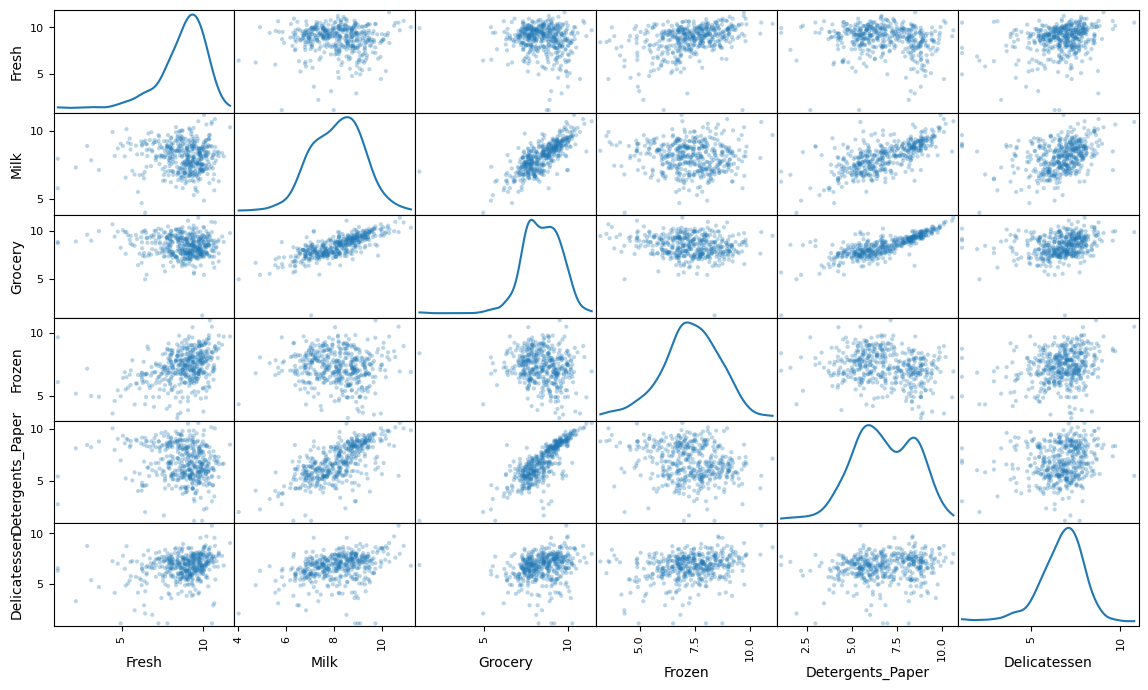

In [10]:
# TODO: Scale the data using the natural logarithm
log_data = np.log(data)

# TODO: Scale the sample data using the natural logarithm
log_samples = np.log(samples)

# Produce a scatter matrix for each pair of newly-transformed features
pd.plotting.scatter_matrix(log_data, alpha = 0.3, figsize = (14,8), diagonal = 'kde');

### Observation
After applying a natural logarithm scaling to the data, the distribution of each feature should appear much more normal. For any pairs of features you may have identified earlier as being correlated, observe here whether that correlation is still present (and whether it is now stronger or weaker than before).

Run the code below to see how the sample data has changed after having the natural logarithm applied to it.

**After applying the natural logarithm transformation, the feature distributions become much closer to a normal distribution and the heavy right skew is significantly reduced. The effect of extreme outliers is also diminished, making the overall structure of the data easier to analyze. The strong correlations between Grocery, Milk, and Detergents_Paper remain visible and are easier to observe after the transformation. This indicates that the relationships identified earlier are genuine and not caused solely by outliers. Overall, the transformed data is more appropriate for dimensionality reduction and clustering techniques such as PCA and K-Means.**

In [11]:
# Display the log-transformed sample data
display(log_samples)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,9.446913,9.175335,8.930759,5.365976,7.891331,7.198931
1,9.403107,8.070594,8.850088,6.173786,8.051978,6.300786
2,8.756682,9.083416,8.946896,7.785305,8.165079,8.967504


### Implementation: Outlier Detection
Detecting outliers in the data is extremely important in the data preprocessing step of any analysis. The presence of outliers can often skew results which take into consideration these data points. There are many "rules of thumb" for what constitutes an outlier in a dataset. Here, we will use [Tukey's Method for identfying outliers](http://datapigtechnologies.com/blog/index.php/highlighting-outliers-in-your-data-with-the-tukey-method/): An *outlier step* is calculated as 1.5 times the interquartile range (IQR). A data point with a feature that is beyond an outlier step outside of the IQR for that feature is considered abnormal.

In the code block below, you will need to implement the following:
 - Assign the value of the 25th percentile for the given feature to `Q1`. Use `np.percentile` for this.
 - Assign the value of the 75th percentile for the given feature to `Q3`. Again, use `np.percentile`.
 - Assign the calculation of an outlier step for the given feature to `step`.
 - Optionally remove data points from the dataset by adding indices to the `outliers` list.

**NOTE:** If you choose to remove any outliers, ensure that the sample data does not contain any of these points!  
Once you have performed this implementation, the dataset will be stored in the variable `good_data`.

In [12]:
from collections import Counter

outlier_indices = []

for feature in log_data.keys():

    Q1 = np.percentile(log_data[feature], 25)
    Q3 = np.percentile(log_data[feature], 75)
    step = 1.5 * (Q3 - Q1)

    feature_outliers = log_data[
        ~((log_data[feature] >= Q1 - step) &
            (log_data[feature] <= Q3 + step))
    ]

    outlier_indices.extend(feature_outliers.index)

# Count occurrences
counter = Counter(outlier_indices)

# Repeated outliers (appear in more than one feature)
repeated_outliers = [idx for idx, count in counter.items() if count > 1]

print("Repeated Outliers:", repeated_outliers)

Repeated Outliers: [65, 66, 128, 154, 75]


In [13]:
# For each feature find the data points with extreme high or low values
for feature in log_data.keys():
    
    # TODO: Calculate Q1 (25th percentile of the data) for the given feature
    Q1 = np.percentile(log_data[feature], 25)
    
    # TODO: Calculate Q3 (75th percentile of the data) for the given feature
    Q3 = np.percentile(log_data[feature], 75)
    
    # TODO: Use the interquartile range to calculate an outlier step (1.5 times the interquartile range)
    step = 1.5 * (Q3 - Q1)
    
    # Display the outliers
    print("Data points considered outliers for the feature '{}':".format(feature))
    display(log_data[~((log_data[feature] >= Q1 - step) & (log_data[feature] <= Q3 + step))])
    
# OPTIONAL: Select the indices for data points you wish to remove
outliers  = [65, 66, 75, 128, 154]

# Remove the outliers, if any were specified
good_data = log_data.drop(log_data.index[outliers]).reset_index(drop = True)

Data points considered outliers for the feature 'Fresh':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
65,4.442651,9.950323,10.732651,3.583519,10.095388,7.260523
66,2.197225,7.335634,8.911530,5.164786,8.151333,3.295837
81,5.389072,9.163249,9.575192,5.645447,8.964184,5.049856
95,1.098612,7.979339,8.740657,6.086775,5.407172,6.563856
96,3.135494,7.869402,9.001839,4.976734,8.262043,5.379897
128,4.941642,9.087834,8.248791,4.955827,6.967909,1.098612
171,5.298317,10.160530,9.894245,6.478510,9.079434,8.740337
193,5.192957,8.156223,9.917982,6.865891,8.633731,6.501290
218,2.890372,8.923191,9.629380,7.158514,8.475746,8.759669
304,5.081404,8.917311,10.117510,6.424869,9.374413,7.787382


Data points considered outliers for the feature 'Milk':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
86,10.039983,11.205013,10.377047,6.894670,9.906981,6.805723
98,6.220590,4.718499,6.656727,6.796824,4.025352,4.882802
154,6.432940,4.007333,4.919981,4.317488,1.945910,2.079442
356,10.029503,4.897840,5.384495,8.057377,2.197225,6.306275


Data points considered outliers for the feature 'Grocery':


...

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
38,8.431853,9.663261,9.723703,3.496508,8.847360,6.070738
57,8.597297,9.203618,9.257892,3.637586,8.932213,7.156177
65,4.442651,9.950323,10.732651,3.583519,10.095388,7.260523
145,10.000569,9.034080,10.457143,3.737670,9.440738,8.396155
175,7.759187,8.967632,9.382106,3.951244,8.341887,7.436617
264,6.978214,9.177714,9.645041,4.110874,8.696176,7.142827
325,10.395650,9.728181,9.519735,11.016479,7.148346,8.632128
420,8.402007,8.569026,9.490015,3.218876,8.827321,7.239215
429,9.060331,7.467371,8.183118,3.850148,4.430817,7.824446
439,7.932721,7.437206,7.828038,4.174387,6.167516,3.951244


Data points considered outliers for the feature 'Detergents_Paper':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
75,9.923192,7.036148,1.098612,8.390949,1.098612,6.882437
161,9.428190,6.291569,5.645447,6.995766,1.098612,7.711101


Data points considered outliers for the feature 'Delicatessen':


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
66,2.197225,7.335634,8.911530,5.164786,8.151333,3.295837
109,7.248504,9.724899,10.274568,6.511745,6.728629,1.098612
128,4.941642,9.087834,8.248791,4.955827,6.967909,1.098612
137,8.034955,8.997147,9.021840,6.493754,6.580639,3.583519
142,10.519646,8.875147,9.018332,8.004700,2.995732,1.098612
154,6.432940,4.007333,4.919981,4.317488,1.945910,2.079442
183,10.514529,10.690808,9.911952,10.505999,5.476464,10.777768
184,5.789960,6.822197,8.457443,4.304065,5.811141,2.397895
187,7.798933,8.987447,9.192075,8.743372,8.148735,1.098612
203,6.368187,6.529419,7.703459,6.150603,6.860664,2.890372


### Question 4
* Are there any data points considered outliers for more than one feature based on the definition above? 
* Should these data points be removed from the dataset? 
* If any data points were added to the `outliers` list to be removed, explain why.

** Hint: ** If you have datapoints that are outliers in multiple categories think about why that may be and if they warrant removal. Also note how k-means is affected by outliers and whether or not this plays a factor in your analysis of whether or not to remove them.

**Answer:**

**Yes, several data points were identified as outliers in more than one feature. These observations represent customers with purchasing patterns that are unusually different from the majority of customers across multiple product categories.**

**Since the goal of this project is to perform customer segmentation using clustering techniques such as K-Means, removing these repeated outliers is reasonable. K-Means is sensitive to extreme values because cluster centroids are based on distances, and a few extreme observations can disproportionately influence the cluster centers.**

**Therefore, the data points that were outliers in multiple features were added to the outliers list and removed from the dataset. Removing them helps produce more representative clusters and reduces the risk that a small number of unusual customers dominate the clustering results.**

**The repeated outliers identified were 65, 66, 75, 128, and 154, and these observations were removed because they were considered extreme in multiple product categories.**

## Feature Transformation
In this section you will use principal component analysis (PCA) to draw conclusions about the underlying structure of the wholesale customer data. Since using PCA on a dataset calculates the dimensions which best maximize variance, we will find which compound combinations of features best describe customers.

### Implementation: PCA

Now that the data has been scaled to a more normal distribution and has had any necessary outliers removed, we can now apply PCA to the `good_data` to discover which dimensions about the data best maximize the variance of features involved. In addition to finding these dimensions, PCA will also report the *explained variance ratio* of each dimension — how much variance within the data is explained by that dimension alone. Note that a component (dimension) from PCA can be considered a new "feature" of the space, however it is a composition of the original features present in the data.

In the code block below, you will need to implement the following:
 - Import `sklearn.decomposition.PCA` and assign the results of fitting PCA in six dimensions with `good_data` to `pca`.
 - Apply a PCA transformation of `log_samples` using `pca.transform`, and assign the results to `pca_samples`.

The workflow for visualizing multi-class data, particularly for high-dimensional and unlabeled datasets, follows a specific logical sequence: starting with K-means to establish categories and then utilizing PCA for visual representation.

### Logical Sequence: K-means then PCA

| Step           | Process                      | Purpose                                                                                                                                                                                  |
| :------------- | :--------------------------- | :--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **1. K-means** | **Label Prediction**         | For **unlabeled data** where the class of each record is unknown, K-means is used to predict class labels by clustering data records into distinct groups (e.g., Cluster 0, Cluster 1).  |
| **2. PCA**     | **Dimensionality Reduction** | High-dimensional data (e.g., 64x1 vectors in the "DIGITS" dataset) cannot be directly plotted. PCA reduces these records to **2-D or 3-D** so they can be visualized on a standard plot. |

### Why This Order is Necessary

  * **Establishing Visual Parameters:** K-means provides the "predicted labels" used to define colors for individual records or background segments in a visualization. Without these labels, the final plot would lack the necessary differentiation to distinguish between classes.
  * **Facilitating Model Evaluation:** By performing K-means first, you can later compare the **Predicted results** against the **Original Labels (Ground Truth)** on the same PCA-reduced 2-D plot to evaluate how accurately the clustering algorithm performed.
  * **Managing Complexity:** Using PCA after clustering ensures that the visualization is not only categorized but also interpretable, overcoming the challenge of visual clutter in complex datasets.

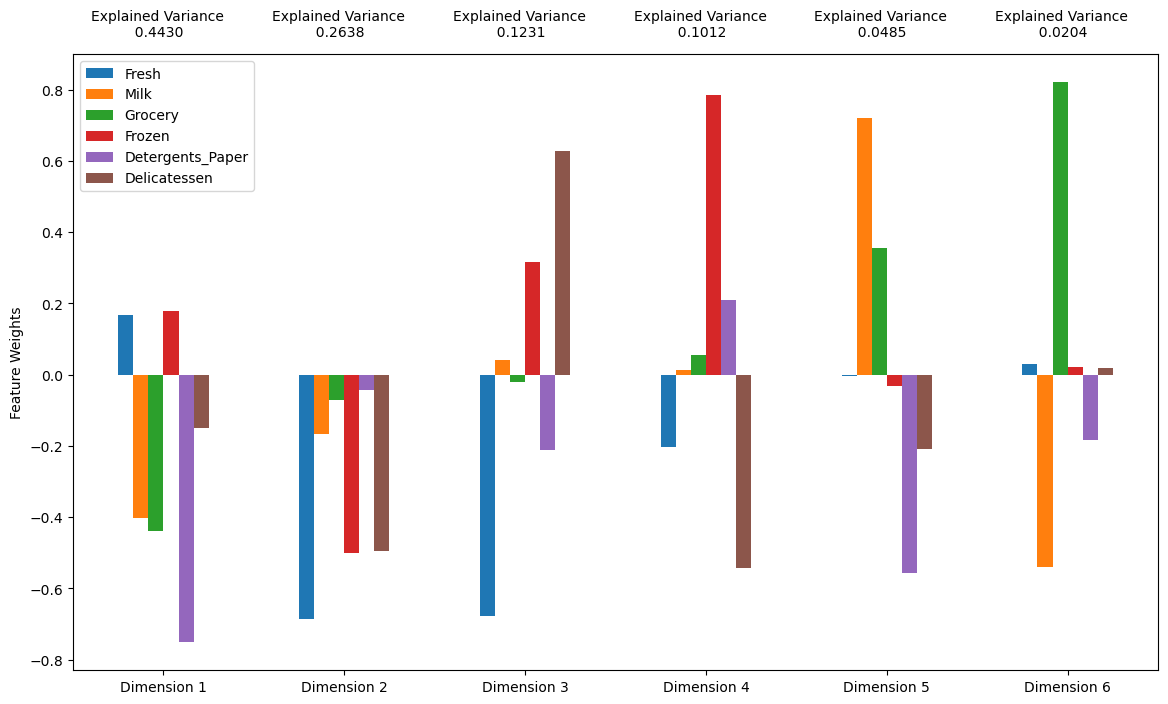

In [14]:
from sklearn.decomposition import PCA

# TODO: Apply PCA by fitting the good data with the same number of dimensions as features
pca = PCA(n_components = 6)
pca.fit(good_data)
# TODO: Transform log_samples using the PCA fit above
pca_samples = pca.transform(log_samples)

# Generate PCA results plot
pca_results = vs.pca_results(good_data, pca)

### Question 5

* How much variance in the data is explained* **in total** *by the first and second principal component? 
* How much variance in the data is explained by the first four principal components? 
* Using the visualization provided above, talk about each dimension and the cumulative variance explained by each, stressing upon which features are well represented by each dimension(both in terms of positive and negative variance explained). Discuss what the first four dimensions best represent in terms of customer spending.

**Hint:** A positive increase in a specific dimension corresponds with an *increase* of the *positive-weighted* features and a *decrease* of the *negative-weighted* features. The rate of increase or decrease is based on the individual feature weights.

**Answer:**

The first principal component (PC1) explains 44.30% of the variance in the dataset, while the second principal component (PC2) explains 26.38%. Together, the first two principal components explain:

**44.30% + 26.38% = 70.68%**

of the total variance in the data.

The first four principal components explain:

* PC1 = 44.30%
* PC2 = 26.38%
* PC3 = 12.31%
* PC4 = 10.12%

giving a cumulative explained variance of:

**44.30% + 26.38% + 12.31% + 10.12% = 93.11%**

Therefore, the first four dimensions retain 93.11% of the information contained in the original six features.

* Dimension 1 (44.30%) is primarily influenced by Detergents_Paper (-0.75), Grocery (-0.44), and Milk (-0.40). This dimension represents customers with strong spending patterns in retail and household products, such as supermarkets and convenience stores.

* Dimension 2 (26.38%) is dominated by Fresh (-0.69), Frozen (-0.50), and Delicatessen (-0.50). This dimension captures customers focused on fresh and food-service products, such as restaurants, cafés, and hotels.

* Dimension 3 (12.31%) is mainly characterized by Delicatessen (+0.63) and Fresh (-0.68), distinguishing customers who spend heavily on delicatessen products from those who spend more on fresh products.

* Dimension 4 (10.12%) is dominated by Frozen (+0.79) and Delicatessen (-0.54), separating customers based on frozen-food purchases versus delicatessen purchases.

**Overall, the first two principal components provide a good low-dimensional representation of the data by capturing 70.68% of the variance, while the first four components preserve 93.11% of the total variance and therefore retain almost all of the information in the original dataset.**

### Observation
Run the code below to see how the log-transformed sample data has changed after having a PCA transformation applied to it in six dimensions. Observe the numerical value for the first four dimensions of the sample points. Consider if this is consistent with your initial interpretation of the sample points.

In [15]:
# Display sample log-data after having a PCA transformation applied
display(pd.DataFrame(np.round(pca_samples, 4), columns = pca_results.index.values))

,Dimension 1,Dimension 2,Dimension 3,Dimension 4,Dimension 5,Dimension 6
0,-1.7580,0.0097,-0.9590,-1.6824,0.2680,-0.3891
1,-1.1286,0.2629,-1.3162,-0.5369,-0.4836,0.1097
2,-1.8834,-1.5991,1.3204,-0.5432,-0.3934,-0.3117


### Implementation: Dimensionality Reduction
When using principal component analysis, one of the main goals is to reduce the dimensionality of the data — in effect, reducing the complexity of the problem. Dimensionality reduction comes at a cost: Fewer dimensions used implies less of the total variance in the data is being explained. Because of this, the *cumulative explained variance ratio* is extremely important for knowing how many dimensions are necessary for the problem. Additionally, if a signifiant amount of variance is explained by only two or three dimensions, the reduced data can be visualized afterwards.

In the code block below, you will need to implement the following:
 - Assign the results of fitting PCA in two dimensions with `good_data` to `pca`.
 - Apply a PCA transformation of `good_data` using `pca.transform`, and assign the results to `reduced_data`.
 - Apply a PCA transformation of `log_samples` using `pca.transform`, and assign the results to `pca_samples`.

In [16]:
# TODO: Apply PCA by fitting the good data with only two dimensions
pca = PCA(n_components=2)
pca.fit(good_data)

# TODO: Transform the good data using the PCA fit above
reduced_data = pca.transform(good_data)

# TODO: Transform log_samples using the PCA fit above
pca_samples = pca.transform(log_samples)

# Create a DataFrame for the reduced data
reduced_data = pd.DataFrame(reduced_data, columns = ['Dimension 1', 'Dimension 2'])

### Observation
Run the code below to see how the log-transformed sample data has changed after having a PCA transformation applied to it using only two dimensions. Observe how the values for the first two dimensions remains unchanged when compared to a PCA transformation in six dimensions.

In [17]:
# Display sample log-data after applying PCA transformation in two dimensions
display(pd.DataFrame(np.round(pca_samples, 4), columns = ['Dimension 1', 'Dimension 2']))

,Dimension 1,Dimension 2
0,-1.7580,0.0097
1,-1.1286,0.2629
2,-1.8834,-1.5991


## Visualizing a Biplot
A biplot is a scatterplot where each data point is represented by its scores along the principal components. The axes are the principal components (in this case `Dimension 1` and `Dimension 2`). In addition, the biplot shows the projection of the original features along the components. A biplot can help us interpret the reduced dimensions of the data, and discover relationships between the principal components and original features.

Run the code cell below to produce a biplot of the reduced-dimension data.

<Axes: title={'center': 'PC plane with original feature projections.'}, xlabel='Dimension 1', ylabel='Dimension 2'>

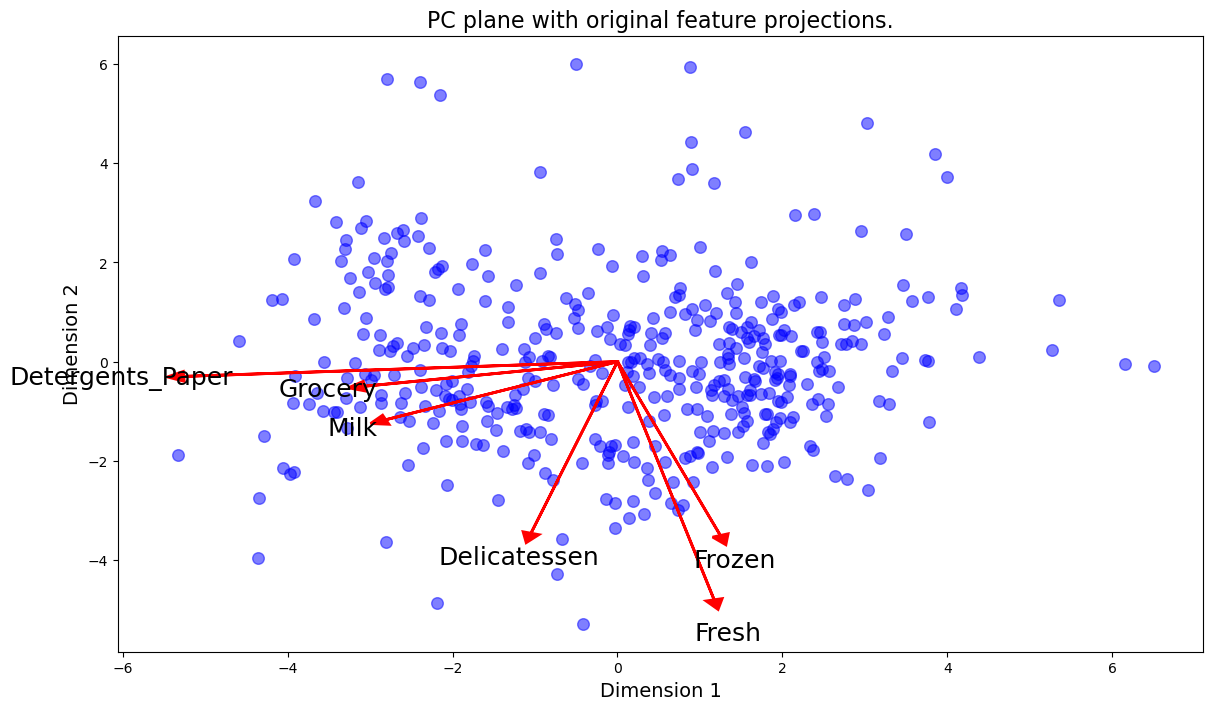

In [18]:
# Create a biplot
vs.biplot(good_data, reduced_data, pca)

### Observation

Once we have the original feature projections (in red), it is easier to interpret the relative position of each data point in the scatterplot. For instance, a point the lower right corner of the figure will likely correspond to a customer that spends a lot on `'Milk'`, `'Grocery'` and `'Detergents_Paper'`, but not so much on the other product categories. 

From the biplot, which of the original features are most strongly correlated with the first component? What about those that are associated with the second component? Do these observations agree with the pca_results plot you obtained earlier?

## Clustering

In this section, you will choose to use either a K-Means clustering algorithm or a Gaussian Mixture Model clustering algorithm to identify the various customer segments hidden in the data. You will then recover specific data points from the clusters to understand their significance by transforming them back into their original dimension and scale. 

### Question 6

* What are the advantages to using a K-Means clustering algorithm? 
* What are the advantages to using a Gaussian Mixture Model clustering algorithm? 
* Given your observations about the wholesale customer data so far, which of the two algorithms will you use and why?

** Hint: ** Think about the differences between hard clustering and soft clustering and which would be appropriate for our dataset.

**Answer:**
**K-Means Advantages**

* Simple and fast.
* Scales well to large datasets.
* Easy to interpret.
* Assigns each customer to exactly one cluster (hard clustering).

Example:

Customer A → Cluster 0

Customer B → Cluster 1

**Gaussian Mixture Model (GMM) Advantages**
* More flexible than K-Means.
* Can model overlapping clusters.
* Provides probabilities (soft clustering).

Example:

Customer A:

70% Cluster 0

30% Cluster 1

This is useful when customers exhibit characteristics of multiple segments.

**K-Means is simple, computationally efficient, and easy to interpret, but it performs hard clustering by assigning each customer to a single cluster. Gaussian Mixture Models (GMM) perform soft clustering by assigning probabilities of membership to each cluster, making them more flexible when clusters overlap. Since the wholesale customer data does not appear to have clearly separated groups and customers may share characteristics of multiple segments, I would choose GMM because it can better model overlapping customer behaviors and provide a more realistic representation of customer segments.**

### Implementation: Creating Clusters
Depending on the problem, the number of clusters that you expect to be in the data may already be known. When the number of clusters is not known *a priori*, there is no guarantee that a given number of clusters best segments the data, since it is unclear what structure exists in the data — if any. However, we can quantify the "goodness" of a clustering by calculating each data point's *silhouette coefficient*. The [silhouette coefficient](http://scikit-learn.org/stable/modules/generated/sklearn.metrics.silhouette_score.html) for a data point measures how similar it is to its assigned cluster from -1 (dissimilar) to 1 (similar). Calculating the *mean* silhouette coefficient provides for a simple scoring method of a given clustering.

In the code block below, you will need to implement the following:
 - Fit a clustering algorithm to the `reduced_data` and assign it to `clusterer`.
 - Predict the cluster for each data point in `reduced_data` using `clusterer.predict` and assign them to `preds`.
 - Find the cluster centers using the algorithm's respective attribute and assign them to `centers`.
 - Predict the cluster for each sample data point in `pca_samples` and assign them `sample_preds`.
 - Import `sklearn.metrics.silhouette_score` and calculate the silhouette score of `reduced_data` against `preds`.
   - Assign the silhouette score to `score` and print the result.

In [19]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score

for n in range(2, 11):
    clusterer = GaussianMixture(n_components=n, random_state=42)
    clusterer.fit(reduced_data)

    preds = clusterer.predict(reduced_data)

    score = silhouette_score(reduced_data, preds)

    print(n, score)

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Wi

2 0.42191684646261485
3 0.4042487382407879
4 0.2932695648465841
5 0.3004563887252593
6 0.32613945047115767
7 0.3242272053843606
8 0.29647665639724213
9 0.3071874795794863
10 0.3103510817791853


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


In [20]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# TODO: Apply your clustering algorithm of choice to the reduced data 
clusterer = GaussianMixture(n_components=2 , random_state=42, n_init=1)
clusterer.fit(reduced_data)

# TODO: Predict the cluster for each data point
preds = clusterer.predict(reduced_data)

# TODO: Find the cluster centers
centers = clusterer.means_

# TODO: Predict the cluster for each transformed sample data point
sample_preds = clusterer.predict(pca_samples)

# TODO: Calculate the mean silhouette coefficient for the number of clusters chosen
score = silhouette_score(reduced_data, preds)
print(score)

0.42191684646261485


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fit K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(reduced_data)

# Predictions
k_preds = kmeans.predict(reduced_data)

# Centers
k_centers = kmeans.cluster_centers_

# Sample customers
k_sample_preds = kmeans.predict(pca_samples)

# Silhouette score
k_score = silhouette_score(reduced_data, k_preds)

print("K-Means Silhouette Score:", k_score)
print("Sample Predictions:", k_sample_preds)

K-Means Silhouette Score: 0.4262810154691084
Sample Predictions: [1 1 1]


c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


**Both K-Means and Gaussian Mixture Models achieved very similar silhouette scores (approximately 0.42), indicating comparable cluster quality. This suggests that the customer segments are reasonably well separated in the PCA-reduced space and that the additional flexibility of GMM does not significantly improve cluster separation. However, GMM still offers the advantage of soft clustering by providing membership probabilities, which can be useful when customers exhibit characteristics of multiple segments.**

### Question 7

* Report the silhouette score for several cluster numbers you tried. 
* Of these, which number of clusters has the best silhouette score?

**Answer:**

**I tested several cluster numbers ranging from 2 to 10 and evaluated each using the silhouette score. The highest silhouette score was obtained when k = 2, with a score of 0.4219. All other cluster counts produced lower scores, indicating weaker separation between clusters. Therefore, 2 clusters appear to provide the best clustering structure for this dataset according to the silhouette metric.**

### Cluster Visualization
Once you've chosen the optimal number of clusters for your clustering algorithm using the scoring metric above, you can now visualize the results by executing the code block below. Note that, for experimentation purposes, you are welcome to adjust the number of clusters for your clustering algorithm to see various visualizations. The final visualization provided should, however, correspond with the optimal number of clusters. 

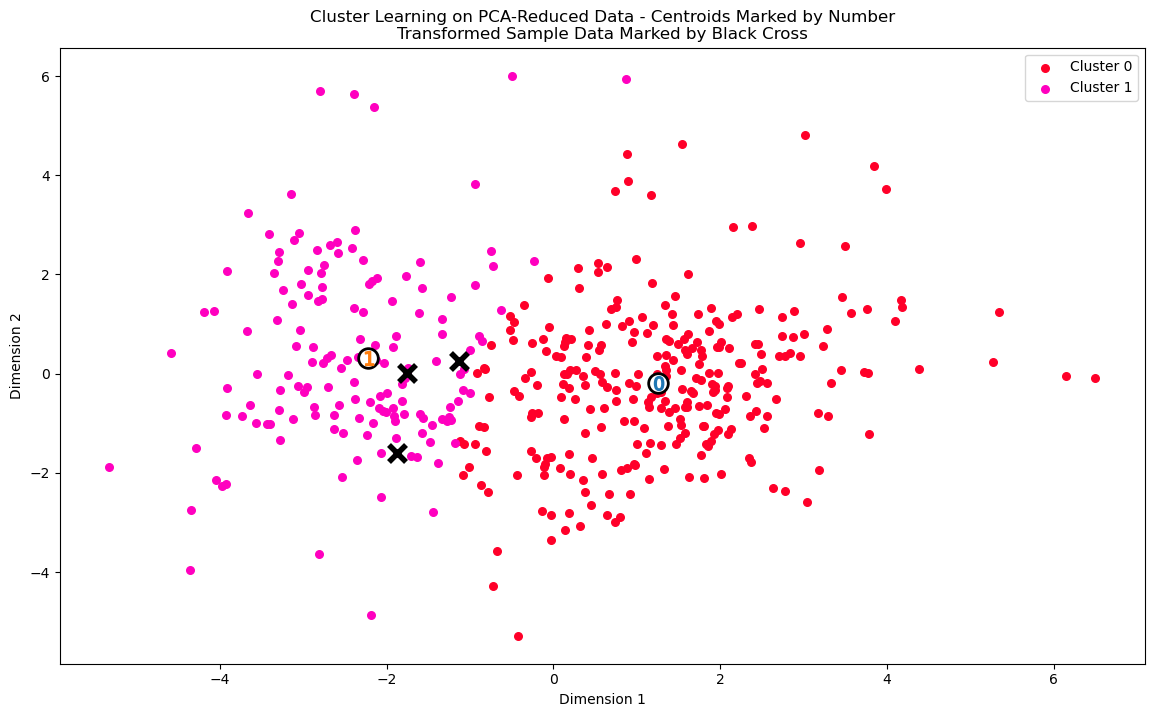

In [22]:
# Display the results of the clustering from implementation
vs.cluster_results(reduced_data, preds, centers, pca_samples)

In [23]:
clusterer.predict_proba(pca_samples)

c:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but GaussianMixture was fitted with feature names
  warnings.warn(


array([[0.14702986, 0.85297014],
       [0.35405893, 0.64594107],
       [0.2145795 , 0.7854205 ]])

### Implementation: Data Recovery
Each cluster present in the visualization above has a central point. These centers (or means) are not specifically data points from the data, but rather the *averages* of all the data points predicted in the respective clusters. For the problem of creating customer segments, a cluster's center point corresponds to *the average customer of that segment*. Since the data is currently reduced in dimension and scaled by a logarithm, we can recover the representative customer spending from these data points by applying the inverse transformations.

In the code block below, you will need to implement the following:
 - Apply the inverse transform to `centers` using `pca.inverse_transform` and assign the new centers to `log_centers`.
 - Apply the inverse function of `np.log` to `log_centers` using `np.exp` and assign the true centers to `true_centers`.


In [24]:
# TODO: Inverse transform the centers
log_centers = pca.inverse_transform(centers)

# TODO: Exponentiate the centers
true_centers = np.exp(log_centers)

# Display the true centers
segments = ['Segment {}'.format(i) for i in range(0,len(centers))]
true_centers = pd.DataFrame(np.round(true_centers), columns = data.keys())
true_centers.index = segments
display(true_centers)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Segment 0,8953.0,2114.0,2765.0,2075.0,353.0,732.0
Segment 1,3552.0,7837.0,12219.0,870.0,4696.0,962.0


### Question 8

* Consider the total purchase cost of each product category for the representative data points above, and reference the statistical description of the dataset at the beginning of this project(specifically looking at the mean values for the various feature points). What set of establishments could each of the customer segments represent?

**Hint:** A customer who is assigned to `'Cluster X'` should best identify with the establishments represented by the feature set of `'Segment X'`. Think about what each segment represents in terms their values for the feature points chosen. Reference these values with the mean values to get some perspective into what kind of establishment they represent.

**Answer:**

- **Segment 0 appears to represent restaurants, hotels, and food-service establishments because it spends heavily on Fresh and Frozen products while spending relatively little on Grocery and Detergents_Paper.**

- **Segment 1 appears to represent retail stores and supermarkets because it spends significantly more than average on Grocery, Milk, and Detergents_Paper, suggesting purchases intended for resale rather than food preparation. The spending patterns of the recovered cluster centers support these interpretations.**

### Question 9

* For each sample point, which customer segment from* **Question 8** *best represents it? 
* Are the predictions for each sample point consistent with this?*

Run the code block below to find which cluster each sample point is predicted to be.

In [25]:
# Display the predictions
for i, pred in enumerate(sample_preds):
    print("Sample point", i, "predicted to be in Cluster", pred)

Sample point 0 predicted to be in Cluster 1
Sample point 1 predicted to be in Cluster 1
Sample point 2 predicted to be in Cluster 1


In [26]:
display(samples)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,12669,9656,7561,214,2674,1338
1,12126,3199,6975,480,3140,545
2,6353,8808,7684,2405,3516,7844


**Answer:**

**All three sample customers were assigned to Cluster 1, which corresponds to the retail/supermarket segment identified in Question 8. This segment is characterized by high expenditures on Grocery, Milk, and Detergents_Paper products, suggesting that these customers primarily purchase goods for resale rather than food preparation.**

**The predictions are generally consistent with the clustering results, as all three sample points exhibit purchasing patterns that are more similar to the retail-oriented segment than to the food-service segment. However, the Gaussian Mixture Model probabilities showed that Sample 1 had a less certain assignment than the other two samples, indicating that it shares some characteristics with both segments while still being classified as Cluster 1.**

## Conclusion

In this final section, you will investigate ways that you can make use of the clustered data. First, you will consider how the different groups of customers, the ***customer segments***, may be affected differently by a specific delivery scheme. Next, you will consider how giving a label to each customer (which *segment* that customer belongs to) can provide for additional features about the customer data. Finally, you will compare the ***customer segments*** to a hidden variable present in the data, to see whether the clustering identified certain relationships.

### Question 10
Companies will often run [A/B tests](https://en.wikipedia.org/wiki/A/B_testing) when making small changes to their products or services to determine whether making that change will affect its customers positively or negatively. The wholesale distributor is considering changing its delivery service from currently 5 days a week to 3 days a week. However, the distributor will only make this change in delivery service for customers that react positively. 

* How can the wholesale distributor use the customer segments to determine which customers, if any, would react positively to the change in delivery service?*

**Hint:** Can we assume the change affects all customers equally? How can we determine which group of customers it affects the most?

**Answer:**

- **The delivery change should not be assumed to affect all customers equally. The customer segments identified through clustering can be used to run targeted A/B tests.** 

- **Segment 0 (restaurants and food-service businesses) is likely to be more sensitive to reduced delivery frequency because it relies heavily on fresh and frozen products.**

- **Segment 1 (retailers and supermarkets) may be less affected because it primarily purchases grocery and household products that can be stored for longer periods. Therefore, the distributor could first test the reduced delivery schedule on customers in Segment 1 and evaluate the results before applying it more broadly.**

### Question 11
Additional structure is derived from originally unlabeled data when using clustering techniques. Since each customer has a ***customer segment*** it best identifies with (depending on the clustering algorithm applied), we can consider *'customer segment'* as an **engineered feature** for the data. Assume the wholesale distributor recently acquired ten new customers and each provided estimates for anticipated annual spending of each product category. Knowing these estimates, the wholesale distributor wants to classify each new customer to a ***customer segment*** to determine the most appropriate delivery service.  
* How can the wholesale distributor label the new customers using only their estimated product spending and the **customer segment** data?

**Hint:** A supervised learner could be used to train on the original customers. What would be the target variable?

**Answer:**

**Yes. After clustering the original customers, the assigned customer segment can be treated as an engineered feature or label. A supervised classification model can then be trained using the spending categories as input features and the cluster assignments as the target variable. For new customers, the trained classifier can predict the most likely customer segment based on their estimated spending patterns, allowing the distributor to assign the most appropriate delivery service without rerunning the clustering process.**

### Visualizing Underlying Distributions

At the beginning of this project, it was discussed that the `'Channel'` and `'Region'` features would be excluded from the dataset so that the customer product categories were emphasized in the analysis. By reintroducing the `'Channel'` feature to the dataset, an interesting structure emerges when considering the same PCA dimensionality reduction applied earlier to the original dataset.

Run the code block below to see how each data point is labeled either `'HoReCa'` (Hotel/Restaurant/Cafe) or `'Retail'` the reduced space. In addition, you will find the sample points are circled in the plot, which will identify their labeling.

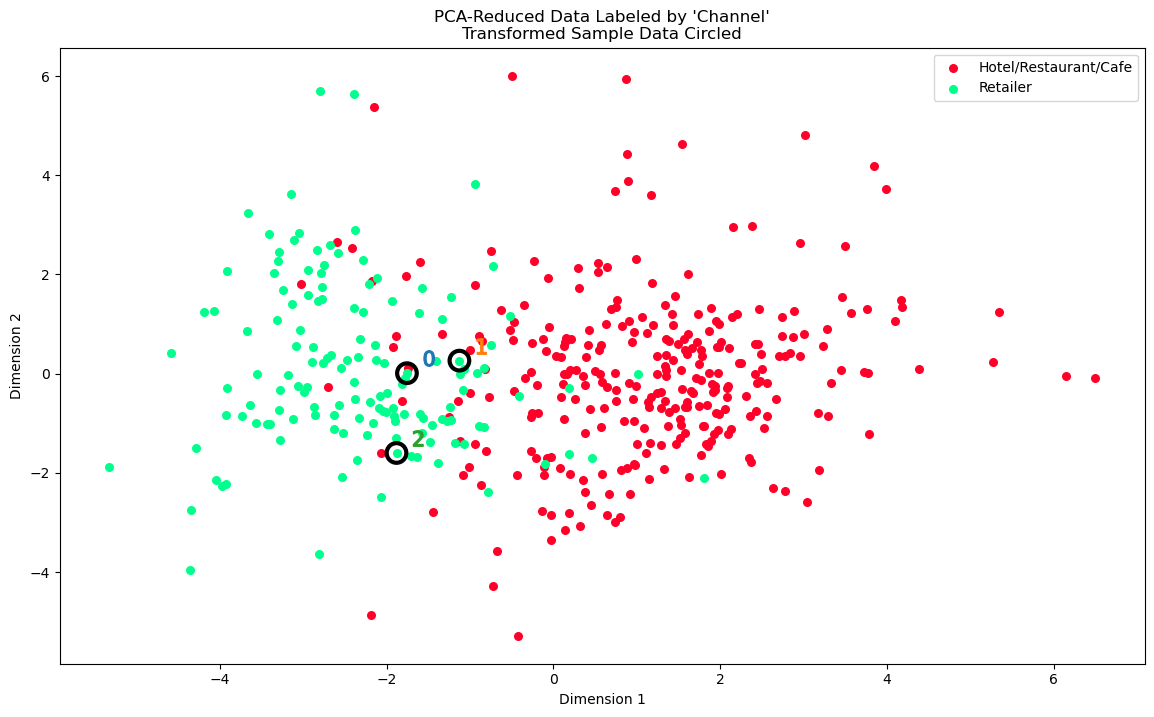

In [27]:
# Display the clustering results based on 'Channel' data
vs.channel_results(reduced_data, outliers, pca_samples)

**The clustering discovered a structure that closely resembles the actual Channel feature, even though the Channel information was never provided to the clustering algorithm. This suggests that customer spending behavior contains enough information to distinguish between Retail customers and HoReCa customers. The three sample customers are located in the region primarily occupied by Retail customers, which is consistent with their assignment to Cluster 1.**

### Question 12

* How well does the clustering algorithm and number of clusters you've chosen compare to this underlying distribution of Hotel/Restaurant/Cafe customers to Retailer customers? 
* Are there customer segments that would be classified as purely 'Retailers' or 'Hotels/Restaurants/Cafes' by this distribution? 
* Would you consider these classifications as consistent with your previous definition of the customer segments?

**Answer:**

- **The clustering algorithm performs reasonably well in capturing the underlying distribution of HoReCa and Retail customers. Although there is some overlap between the two groups, a large proportion of Retail customers are concentrated on one side of the PCA-reduced space, while many HoReCa customers are concentrated on the other side. This indicates that customer spending patterns contain meaningful information about customer type.**

- **However, neither cluster appears to be completely pure. Both regions contain a mixture of HoReCa and Retail customers, suggesting that customer behavior does not perfectly separate into two distinct categories. This overlap is expected because some businesses may exhibit purchasing patterns that resemble both groups.**

- **The results are generally consistent with the customer segments identified earlier. One segment was characterized by high spending on Fresh and Frozen products, which aligns with the behavior of many HoReCa customers. The other segment was characterized by high spending on Grocery, Milk, and Detergents_Paper, which aligns more closely with Retail customers. While the clustering does not perfectly reproduce the Channel labels, it successfully captures the major differences between these two customer types and provides meaningful customer segments for business analysis.**

> **Note**: Once you have completed all of the code implementations and successfully answered each question above, you may finalize your work by exporting the iPython Notebook as an HTML document. You can do this by using the menu above and navigating to  
**File -> Download as -> HTML (.html)**. Include the finished document along with this notebook as your submission.

# PCA and K-Means Summary

## Why PCA?

Our dataset contains 6 features:

- Fresh
- Milk
- Grocery
- Frozen
- Detergents_Paper
- Delicatessen

Since humans cannot visualize data in 6 dimensions, PCA is used to reduce the dataset into 2 principal components (PC1 and PC2) while preserving most of the information.

In this project:

- PC1 explains **44.30%** of the variance.
- PC2 explains **26.38%** of the variance.

Together:

```text
44.30% + 26.38% = 70.68%
```

The first two components preserve about **70.68%** of the original information.

---

## What do PCA values represent?

After PCA, each customer receives new coordinates:

```text
Customer 0 -> (PC1, PC2)
Customer 1 -> (PC1, PC2)
Customer 2 -> (PC1, PC2)
```

These values are not customer types or cluster labels.

They simply represent the customer's position in the new PCA space.

---

## Why track the three sample customers?

The three selected customers act as reference points throughout the analysis.

We first inspect their spending behavior and make assumptions about what type of business they might represent.

After PCA, we check whether the differences between those customers are still preserved.

The goal is not to interpret the PCA coordinates themselves, but to verify that PCA maintains the relative relationships among customers.

---

## PCA vs K-Means

### Option 1: PCA → K-Means

```text
6 Features
    ↓
PCA
    ↓
2 Principal Components
    ↓
K-Means
    ↓
Clusters
```

Advantages:
- Faster computation.
- Easier visualization.
- Can remove noise.

Disadvantages:
- Some information may be lost.
- Important cluster separation could disappear.

---

### Option 2: K-Means → PCA (Visualization Only)

```text
6 Features
    ↓
K-Means
    ↓
Cluster Labels
    ↓
PCA
    ↓
2D Visualization
```

Advantages:
- Clustering uses all original information.
- No risk of PCA affecting cluster assignments.

Disadvantages:
- Visualization may not perfectly represent the original high-dimensional structure.

---

## Important Note

Even if clustering is performed on the original 6-dimensional data, dimensionality reduction is still required for visualization.

Therefore, PCA is often used at the end of the process to display the clusters on a 2D plot.

---

## Key Takeaway

PCA does not create clusters.

PCA only transforms the data into a lower-dimensional representation.

The actual customer segmentation is performed by clustering algorithms such as K-Means.

PCA helps us visualize and understand the data, while K-Means identifies groups of similar customers.

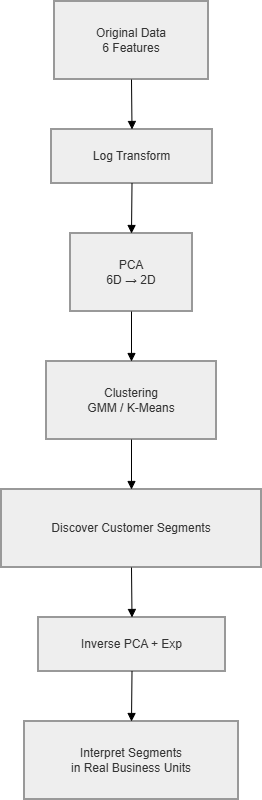

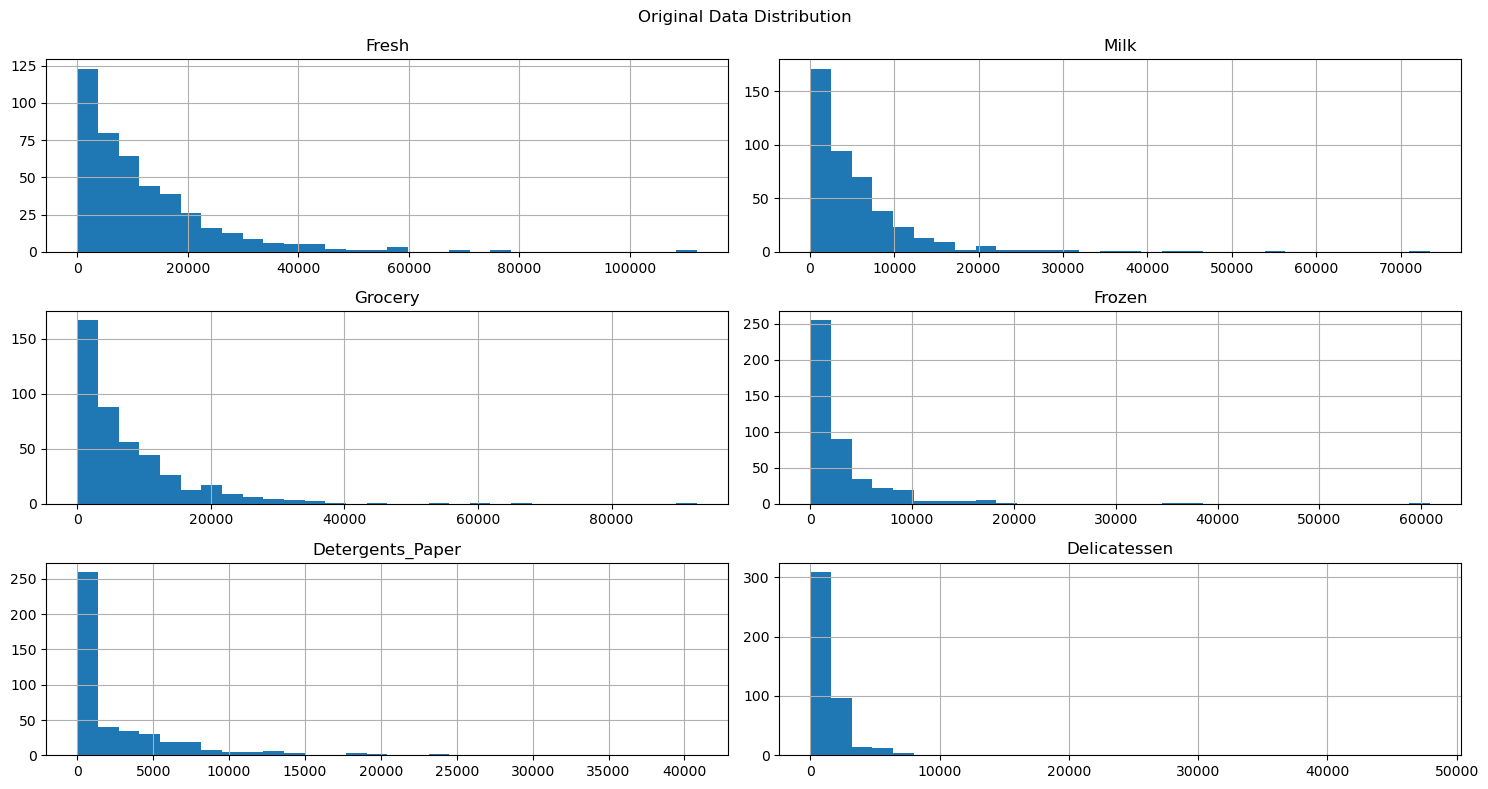

In [28]:
import matplotlib.pyplot as plt

data.hist(figsize=(15,8), bins=30)
plt.suptitle("Original Data Distribution")
plt.tight_layout()
plt.show()

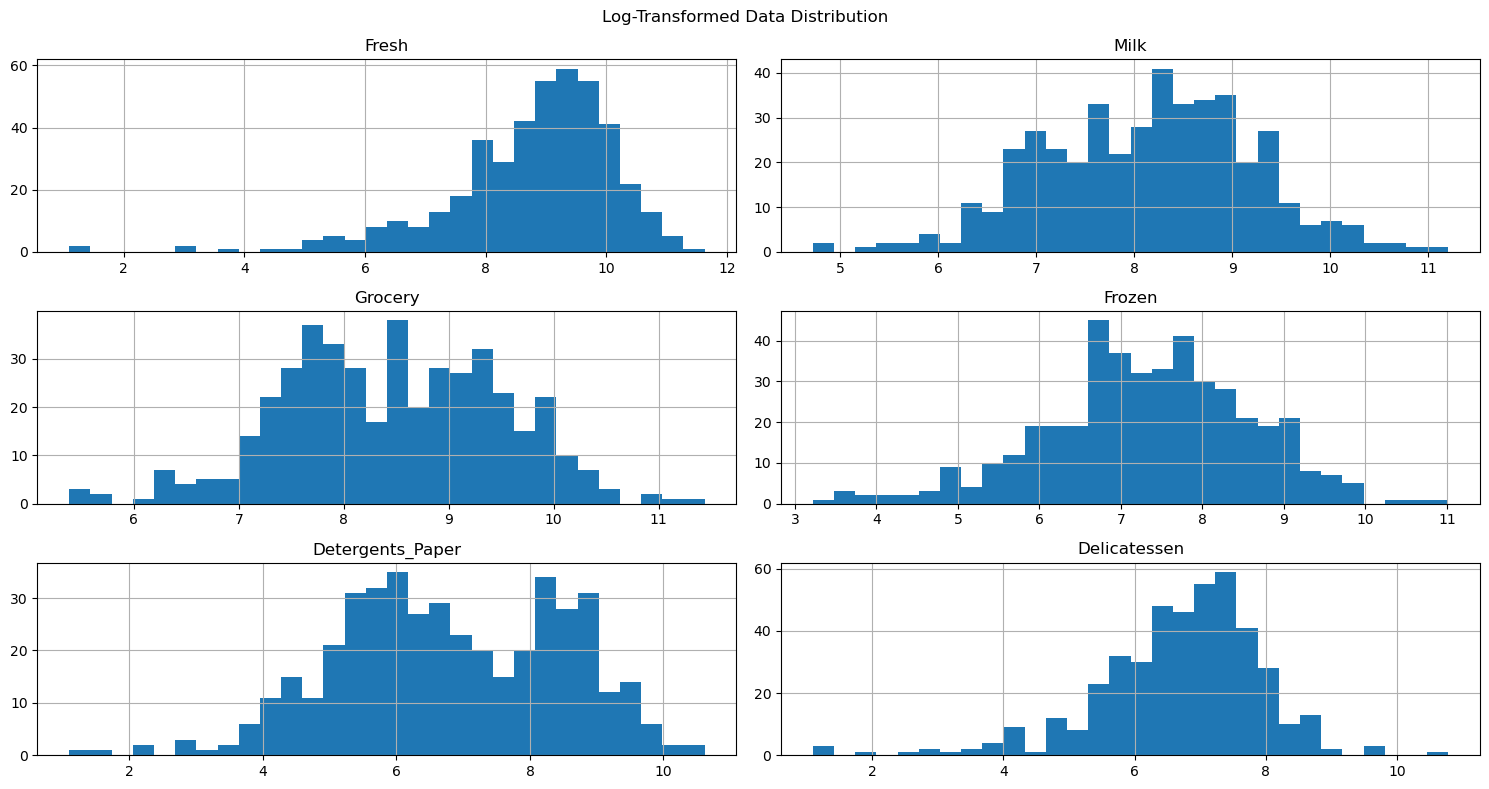

In [29]:
good_data.hist(figsize=(15,8), bins=30)
plt.suptitle("Log-Transformed Data Distribution")
plt.tight_layout()
plt.show()

In [30]:
X = good_data.copy()

y = preds  

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,f1_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Logistic Regression
Accuracy: 0.9885057471264368
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        56
           1       1.00      0.97      0.98        31

    accuracy                           0.99        87
   macro avg       0.99      0.98      0.99        87
weighted avg       0.99      0.99      0.99        87



In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Random Forest
Accuracy: 0.9770114942528736
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        56
           1       0.97      0.97      0.97        31

    accuracy                           0.98        87
   macro avg       0.97      0.97      0.97        87
weighted avg       0.98      0.98      0.98        87



In [34]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))

XGBoost
Accuracy: 0.9655172413793104
              precision    recall  f1-score   support

           0       0.96      0.98      0.97        56
           1       0.97      0.94      0.95        31

    accuracy                           0.97        87
   macro avg       0.97      0.96      0.96        87
weighted avg       0.97      0.97      0.97        87



In [35]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "F1-Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

results.sort_values("F1-Score", ascending=False)

,Model,F1-Score
0,Logistic Regression,0.983607
1,Random Forest,0.967742
2,XGBoost,0.950820


In [36]:
import joblib

joblib.dump(lr, "customer_segment_classifier.pkl")

['customer_segment_classifier.pkl']

In [37]:
def predict_segment(fresh, milk, grocery, frozen,
                    detergents, delicatessen):

    customer = pd.DataFrame({
        "Fresh":[fresh],
        "Milk":[milk],
        "Grocery":[grocery],
        "Frozen":[frozen],
        "Detergents_Paper":[detergents],
        "Delicatessen":[delicatessen]
    })

    customer = np.log(customer)

    segment = lr.predict(customer)[0]

    return segment

In [42]:
segment = predict_segment(1000,9000,1000,800,5000,12000)

if segment == 0:
    print("HoReCa → 5 delivery days")
else:
    print("Retail → 3 delivery days")

Retail → 3 delivery days
